### Thoughts on which data/columns to keep + notes on data wrangling done for now

- Columns: keep all except for `Source of income`: more about data collection method than content. Have looked at the distribution and could make small comment on it in thesis, but will be excluded from final data.
- Replaced all #VALUE! with NaNs -> we have 1521 NaN's in the Other vulnerabilities column, no missing values in other columns.
- Split `Sector` column into lists to be able to count the amounts + combinations
    - merged the ones that were the same but e.g. difference was capital/no capital letter (and directions, direction)
- Split `Other vulnerabilities` on comma and make dummy columns for the top 300 (with occurences > 100), then remove original column

### Imports

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
from itertools import combinations

In [117]:
# Visual style for plots
sns.set_theme(style="whitegrid")

### Load and combine data

dataframe needs to be in folder called `data`

In [118]:
df = pd.read_excel('Thesis_data_translated.xlsx')

In [119]:
len(df)

3597

In [120]:
df.head()

,APPLICATION NO.:,Description,Sector,Source of income,Region,Sex,Age group,Invalidity,Other vulnerabilities
0,1,"A local pensioner, 68, suffered a stroke and r...","Humanitarian aid, Directions",Incoming call,Dnipropetrovsk,Women's,60-69,No group,#VALUE!
1,2,The woman asked about the questionnaire that s...,"Directions, LiveLiHood",Incoming call,Kharkiv,Women's,60-69,No group,#VALUE!
2,3,"A woman is in a difficult psychological state,...",Psychosocial support,Incoming call,Vinnytsia,Women's,40-49,No group,Relative of a person who died/disappeared as a...
3,4,A lawyer has contacted me to help a woman (a c...,"Legal aid, Referrals",Incoming call,Odesa,Men's,Not specified,No group,#VALUE!
4,5,The man wants to work at the TCHHU.\nexplained...,LiveLiHood,Incoming call,Lvivska,Men's,Not specified,No group,#VALUE!


### Data Cleaning and Preparation

Replace all #VALUE!'s with NaN's:

In [121]:
# For every #VALUE, replace with NaN
# Replace #VALUE! strings (Excel formula errors) with proper NaN
df['Other vulnerabilities'] = df['Other vulnerabilities'].replace('#VALUE!', pd.NA)
df['Source of income'] = df['Source of income'].replace('#VALUE!', pd.NA)


# Verify
print("Remaining #VALUE! entries:", (df['Other vulnerabilities'] == '#VALUE!').sum())
print("NaN count in Other vulnerabilities:", df['Other vulnerabilities'].isna().sum())
print("NaN count in Source of income:", df['Source of income'].isna().sum())

Remaining #VALUE! entries: 0
NaN count in Other vulnerabilities: 1521
NaN count in Source of income: 4


In [122]:
df.head()

,APPLICATION NO.:,Description,Sector,Source of income,Region,Sex,Age group,Invalidity,Other vulnerabilities
0,1,"A local pensioner, 68, suffered a stroke and r...","Humanitarian aid, Directions",Incoming call,Dnipropetrovsk,Women's,60-69,No group,NaN
1,2,The woman asked about the questionnaire that s...,"Directions, LiveLiHood",Incoming call,Kharkiv,Women's,60-69,No group,NaN
2,3,"A woman is in a difficult psychological state,...",Psychosocial support,Incoming call,Vinnytsia,Women's,40-49,No group,Relative of a person who died/disappeared as a...
3,4,A lawyer has contacted me to help a woman (a c...,"Legal aid, Referrals",Incoming call,Odesa,Men's,Not specified,No group,NaN
4,5,The man wants to work at the TCHHU.\nexplained...,LiveLiHood,Incoming call,Lvivska,Men's,Not specified,No group,NaN


In [123]:
# Check for missing values
print("Missing Values per Column:\n", df.isnull().sum())

Missing Values per Column:
 APPLICATION NO.:            0
Description                 0
Sector                      0
Source of income            4
Region                      0
Sex                         0
Age group                   0
Invalidity                  0
Other vulnerabilities    1521
dtype: int64


Split `Sector` column into lists to be able to count the amounts + combinations:

In [124]:
# Split Sector column on comma into a list per row (strip whitespace from each item)
df['Sector_list'] = df['Sector'].dropna().apply(
    lambda x: [s.strip() for s in str(x).split(',')]
)

# Exploded version for counting/plotting (one row per sector tag)
df_sector_exploded = df.explode('Sector_list').dropna(subset=['Sector_list'])
df_sector_exploded['Sector_list'] = df_sector_exploded['Sector_list'].str.strip()

print("Unique sectors after splitting:", df_sector_exploded['Sector_list'].nunique())
print(df_sector_exploded['Sector_list'].value_counts().sort_index())

Unique sectors after splitting: 41
Sector_list
Crisis                             5
Destinations                       4
Direction                          4
Directions                      1529
Education                         13
Evacuation or Transportation       2
Evacuation or transportation     108
Financial Aid                    283
Financial Assistance              21
Financial aid                     55
Financial assistance             480
Home Care                          5
Home care                         69
Human Health                      47
Human health                     202
Humanitarian Aid                  11
Humanitarian Assistance           12
Humanitarian aid                 955
Humanitarian assistance           50
Incomplete interaction            26
Information                      211
Legal Aid                          2
Legal Assistance                   2
Legal aid                         68
Legal assistance                  12
LiveLiHood                  

Merge ones that are the same:

In [125]:
# Merge near-duplicate sector tags (capitalisation / plural variants)
SECTOR_MAPPING = {
    "Direction":                        "Direction",
    "Directions":                       "Direction",
    "Evacuation or Transportation":     "Evacuation or Transportation",
    "Evacuation or transportation":     "Evacuation or Transportation",
    "Financial Aid":                    "Financial Aid",
    "Financial aid":                    "Financial Aid",
    "Financial Assistance":             "Financial Assistance",
    "Financial assistance":             "Financial Assistance",
    "Home Care":                        "Home Care",
    "Home care":                        "Home Care",
    "Human Health":                     "Human Health",
    "Human health":                     "Human Health",
    "Humanitarian Aid":                 "Humanitarian Aid",
    "Humanitarian aid":                 "Humanitarian Aid",
    "Humanitarian Assistance":          "Humanitarian Assistance",
    "Humanitarian assistance":          "Humanitarian Assistance",
    "Legal Aid":                        "Legal Aid",
    "Legal aid":                        "Legal Aid",
    "Legal Assistance":                 "Legal Assistance",
    "Legal assistance":                 "Legal Assistance",
    "Restoring family ties":            "Restoring family ties",
    "Restoring Family Ties":            "Restoring family ties",
    "Referral":                         "Referral",
    "Referrals":                        "Referral",
    "Unfinished interaction":           "Unfinished Interaction",
    "Unfinished Interaction":           "Unfinished Interaction",

}

# Apply mapping to the already-split lists, leave unmapped tags unchanged
df['Sector_list'] = df['Sector_list'].apply(
    lambda tags: [SECTOR_MAPPING.get(t, t) for t in tags] if isinstance(tags, list) else tags
)

# Rebuild the exploded dataframe with cleaned tags
df_sector_exploded = df.explode('Sector_list').dropna(subset=['Sector_list'])
df_sector_exploded['Sector_list'] = df_sector_exploded['Sector_list'].str.strip()

print("Unique sectors after cleaning:", df_sector_exploded['Sector_list'].nunique())
print(df_sector_exploded['Sector_list'].value_counts())

Unique sectors after cleaning: 28
Sector_list
Direction                       1533
Restoring family ties           1074
Humanitarian Aid                 966
Referral                         730
Financial Assistance             501
Financial Aid                    338
Human Health                     249
Psychosocial support             247
Information                      211
Evacuation or Transportation     110
LiveLiHood                       105
Home Care                         74
Legal Aid                         70
Humanitarian Assistance           62
Offer of help                     54
Shelter                           42
Incomplete interaction            26
Legal Assistance                  14
Unfinished Interaction            14
Other                             13
Education                         13
Crisis                             5
security                           5
protection                         5
Destinations                       4
Teaching                     

In [126]:
df.head()

,APPLICATION NO.:,Description,Sector,Source of income,Region,Sex,Age group,Invalidity,Other vulnerabilities,Sector_list
0,1,"A local pensioner, 68, suffered a stroke and r...","Humanitarian aid, Directions",Incoming call,Dnipropetrovsk,Women's,60-69,No group,NaN,"[Humanitarian Aid, Direction]"
1,2,The woman asked about the questionnaire that s...,"Directions, LiveLiHood",Incoming call,Kharkiv,Women's,60-69,No group,NaN,"[Direction, LiveLiHood]"
2,3,"A woman is in a difficult psychological state,...",Psychosocial support,Incoming call,Vinnytsia,Women's,40-49,No group,Relative of a person who died/disappeared as a...,[Psychosocial support]
3,4,A lawyer has contacted me to help a woman (a c...,"Legal aid, Referrals",Incoming call,Odesa,Men's,Not specified,No group,NaN,"[Legal Aid, Referral]"
4,5,The man wants to work at the TCHHU.\nexplained...,LiveLiHood,Incoming call,Lvivska,Men's,Not specified,No group,NaN,[LiveLiHood]


In [ ]:
# --- Invalidity: group near-duplicate values --- #
# Run df['Invalidity'].value_counts() first to see what exact strings appear.
# Then map variants that mean the same thing to a single canonical label.

INVALIDITY_MAPPING = {
    # "Exact string from data":  "Canonical label",
    "Person with disability - group 2":        "Person with disability",
    "Person with disability - group 3":       "Person with disability",   
    "Person with a disability - 1 group":      "Person with disability",   
    # Add more rows here based on df['Invalidity'].value_counts()
}

df['Invalidity_clean'] = df['Invalidity'].map(INVALIDITY_MAPPING).fillna(df['Invalidity'])

# Renaming to shorter label
df['Invalidity_clean'] = df['Invalidity_clean'].replace('There is no group, but there are significant difficulties', 'No group - significant difficulties')

# Verify — should show only canonical labels + anything unmapped
print(df['Invalidity_clean'].value_counts())

Invalidity_clean
No group                               3050
Person with disability                  501
No group - significant difficulties      41
Disability due to war                     5
Name: count, dtype: int64


In [128]:
df.head()

,APPLICATION NO.:,Description,Sector,Source of income,Region,Sex,Age group,Invalidity,Other vulnerabilities,Sector_list,Invalidity_clean
0,1,"A local pensioner, 68, suffered a stroke and r...","Humanitarian aid, Directions",Incoming call,Dnipropetrovsk,Women's,60-69,No group,NaN,"[Humanitarian Aid, Direction]",No group
1,2,The woman asked about the questionnaire that s...,"Directions, LiveLiHood",Incoming call,Kharkiv,Women's,60-69,No group,NaN,"[Direction, LiveLiHood]",No group
2,3,"A woman is in a difficult psychological state,...",Psychosocial support,Incoming call,Vinnytsia,Women's,40-49,No group,Relative of a person who died/disappeared as a...,[Psychosocial support],No group
3,4,A lawyer has contacted me to help a woman (a c...,"Legal aid, Referrals",Incoming call,Odesa,Men's,Not specified,No group,NaN,"[Legal Aid, Referral]",No group
4,5,The man wants to work at the TCHHU.\nexplained...,LiveLiHood,Incoming call,Lvivska,Men's,Not specified,No group,NaN,[LiveLiHood],No group


Make binary dummy columns for top 3 `Other vulnerabilities` categories (>100):
- Relative of a person who died/disappeared as a result of the war (1020, standalone)
- Internally Displaced Person (IDP) Status (533, standalone)
- Lonely elderly people (103, standalone)

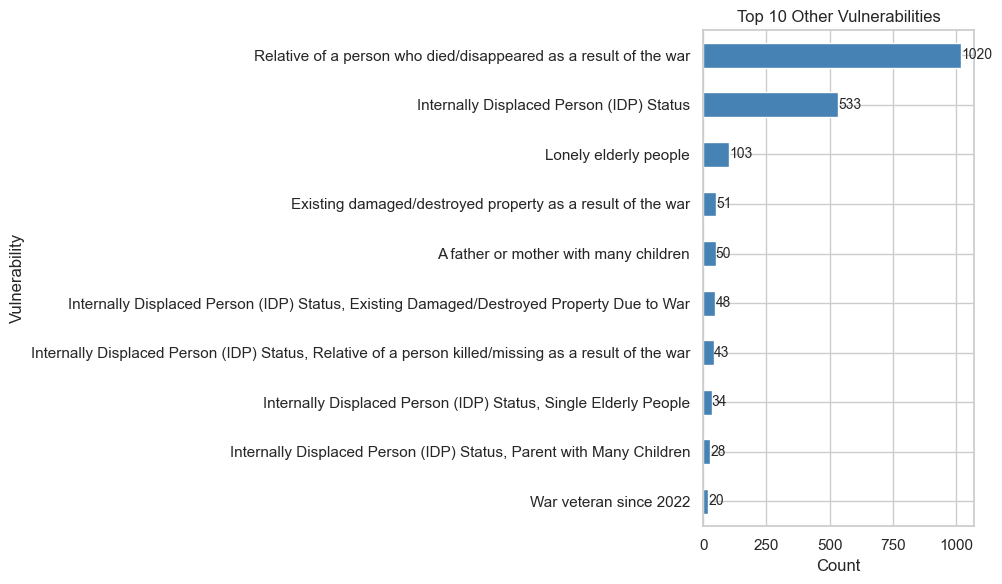

In [129]:
# Show top vulnerability categories
top_n = 10  # adjust as needed

vuln_counts = df['Other vulnerabilities'].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
vuln_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top {top_n} Other Vulnerabilities')
ax.set_xlabel('Count')
ax.set_ylabel('Vulnerability')
ax.invert_yaxis()  # highest count at top


for i, v in enumerate(vuln_counts):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# --- Other vulnerabilities: split on comma and create dummy columns for top 3 --- #

# Split 'Other vulnerabilities' on comma into a list per row (strip whitespace)
df['Vuln_list'] = df['Other vulnerabilities'].dropna().apply(
    lambda x: [v.strip() for v in str(x).split(',')]
)

# Define the top 3 vulnerability strings to create dummies for
TOP_VULNS = {
    'IDP_Status':       'Internally Displaced Person (IDP) Status',
    'Relative_Deceased_Disappeared_War': 'Relative of a person who died/disappeared as a result of the war',
    'Lonely_Elderly':   'Lonely elderly people',
}

# Create a binary Yes/No dummy column for each of the top 3
for col_name, vuln_string in TOP_VULNS.items():
    df[col_name] = df['Vuln_list'].apply(
        lambda tags: 'Yes' if isinstance(tags, list) and vuln_string in tags else 'No'
    )

# Remove the original Other vulnerabilities column (replaced by dummies)
df.drop(columns=['Other vulnerabilities', 'Vuln_list'], inplace=True)

# Verify
print("IDP_Status distribution:")
print(df['IDP_Status'].value_counts())
print("\nRelative_Deceased_Disappeared_War distribution:")
print(df['Relative_Deceased_Disappeared_War'].value_counts())
print("\nLonely_Elderly distribution:")
print(df['Lonely_Elderly'].value_counts())

IDP_Status distribution:
IDP_Status
No     2880
Yes     717
Name: count, dtype: int64

Relative_Deceased_Disappeared_War distribution:
Relative_Deceased_Disappeared_War
No     2561
Yes    1036
Name: count, dtype: int64

Lonely_Elderly distribution:
Lonely_Elderly
No     3479
Yes     118
Name: count, dtype: int64


In [131]:
df.head()

,APPLICATION NO.:,Description,Sector,Source of income,Region,Sex,Age group,Invalidity,Sector_list,Invalidity_clean,IDP_Status,Relative_Deceased_Disappeared_War,Lonely_Elderly
0,1,"A local pensioner, 68, suffered a stroke and r...","Humanitarian aid, Directions",Incoming call,Dnipropetrovsk,Women's,60-69,No group,"[Humanitarian Aid, Direction]",No group,No,No,No
1,2,The woman asked about the questionnaire that s...,"Directions, LiveLiHood",Incoming call,Kharkiv,Women's,60-69,No group,"[Direction, LiveLiHood]",No group,No,No,No
2,3,"A woman is in a difficult psychological state,...",Psychosocial support,Incoming call,Vinnytsia,Women's,40-49,No group,[Psychosocial support],No group,No,Yes,No
3,4,A lawyer has contacted me to help a woman (a c...,"Legal aid, Referrals",Incoming call,Odesa,Men's,Not specified,No group,"[Legal Aid, Referral]",No group,No,No,No
4,5,The man wants to work at the TCHHU.\nexplained...,LiveLiHood,Incoming call,Lvivska,Men's,Not specified,No group,[LiveLiHood],No group,No,No,No


### Distributions

#### Sex

C:\Users\cdegr\AppData\Local\Temp\ipykernel_572\3121747167.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='pastel',


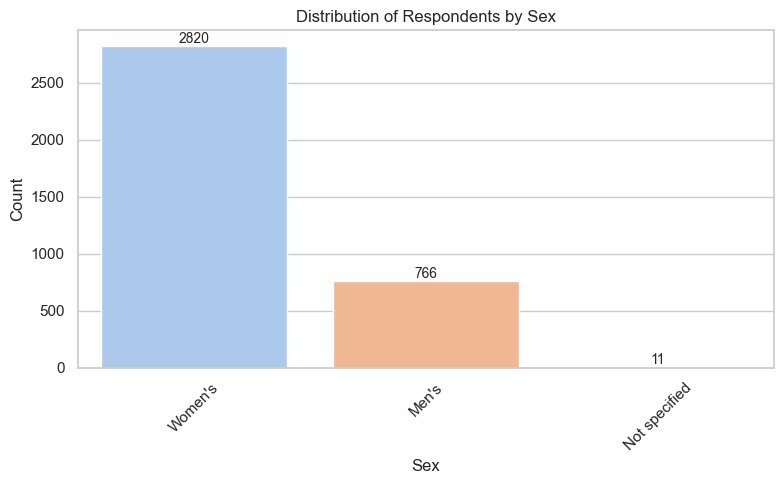

In [132]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Sex', palette='pastel',
              order=df['Sex'].value_counts().index, ax=ax)
ax.set_title('Distribution of Respondents by Sex')
ax.set_xlabel('Sex')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# Add count labels above each bar
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height() + 0.5,
            str(int(p.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#### Sector (after split in tags)

C:\Users\cdegr\AppData\Local\Temp\ipykernel_572\1702632492.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sector_exploded, y='Sector_list', order=order,


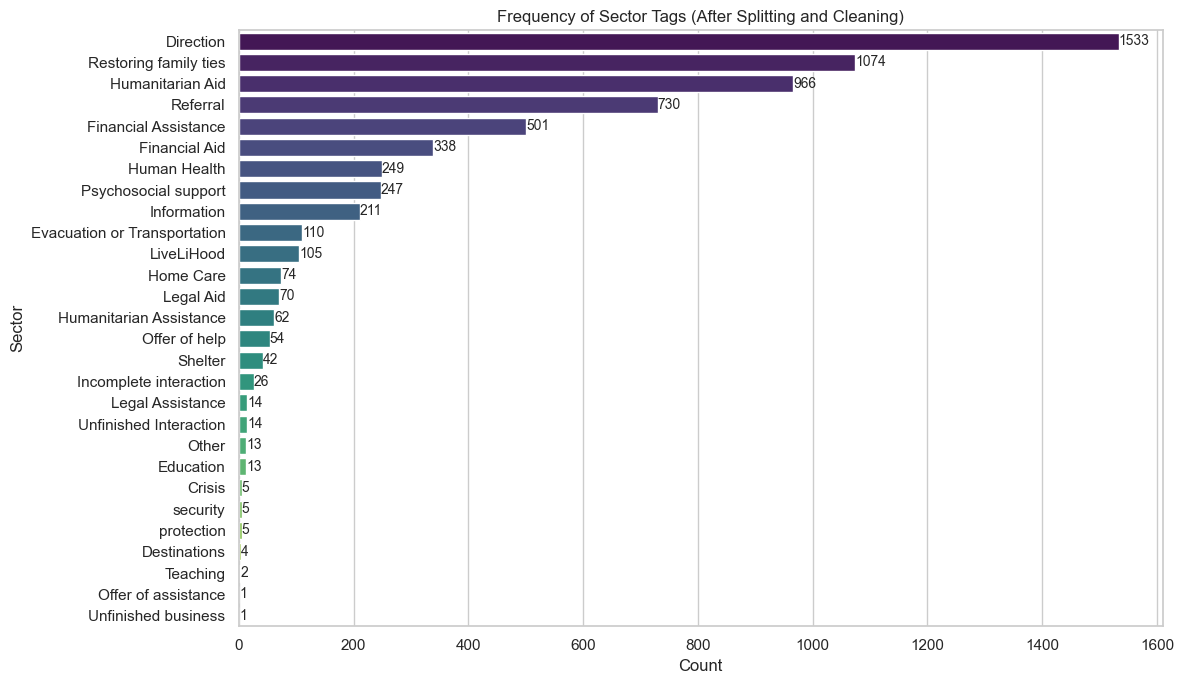

In [133]:
# Distribution of Individual Tags
fig, ax = plt.subplots(figsize=(12, 7))
order = df_sector_exploded['Sector_list'].value_counts().index
sns.countplot(data=df_sector_exploded, y='Sector_list', order=order,
              palette='viridis', ax=ax)
ax.set_title('Frequency of Sector Tags (After Splitting and Cleaning)')
ax.set_xlabel('Count')
ax.set_ylabel('Sector')

for p in ax.patches:
    ax.text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2.,
            str(int(p.get_width())), ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

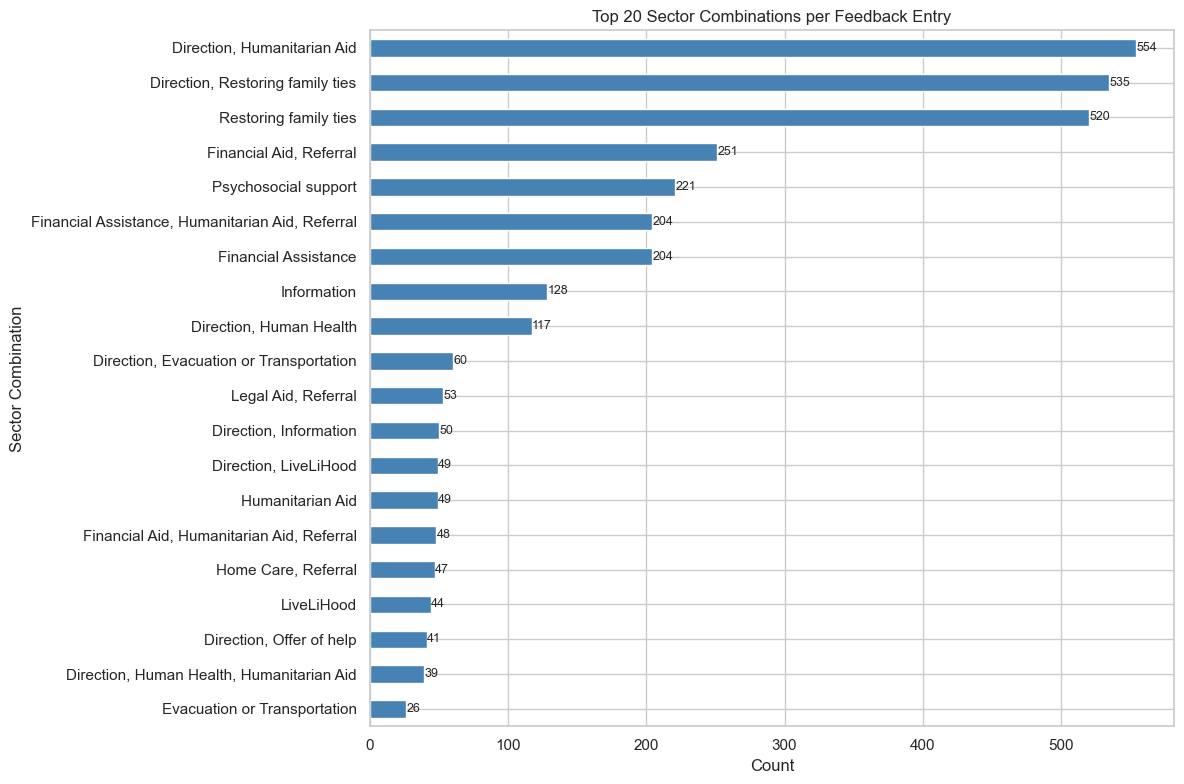

In [134]:
# Combination of tags - Bar Chart

# Rebuild combination strings from cleaned lists for each row
df['Sector_combination'] = df['Sector_list'].apply(
    lambda tags: ', '.join(sorted(set(tags))) if isinstance(tags, list) else None
)

combo_counts = df['Sector_combination'].value_counts()

# Show top N combinations to keep the chart readable
top_n = 20
combo_top = combo_counts.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
combo_top.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top {top_n} Sector Combinations per Feedback Entry')
ax.set_xlabel('Count')
ax.set_ylabel('Sector Combination')
ax.invert_yaxis()  # highest count at top

for i, v in enumerate(combo_top):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

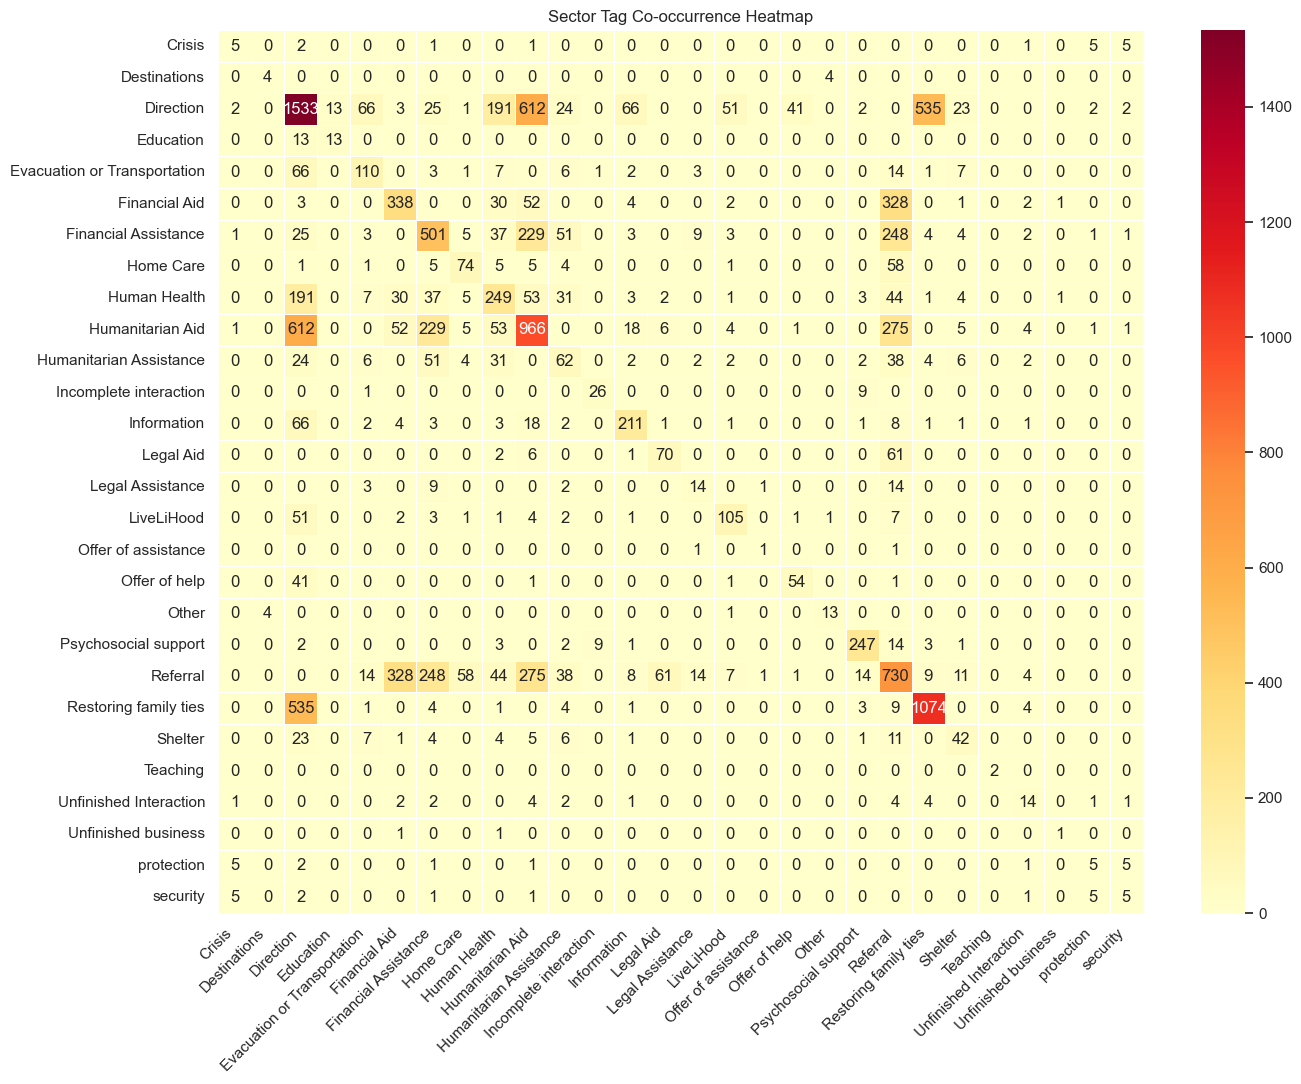

In [135]:
# Combination of tags - Heatmap
all_sectors = sorted(df_sector_exploded['Sector_list'].unique())
cooc = pd.DataFrame(0, index=all_sectors, columns=all_sectors)

for tags in df['Sector_list'].dropna():
    unique_tags = list(set(tags))
    for s in unique_tags:
        cooc.loc[s, s] += 1
    for s1, s2 in combinations(unique_tags, 2):
        cooc.loc[s1, s2] += 1
        cooc.loc[s2, s1] += 1

plt.figure(figsize=(14, 11))
sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Sector Tag Co-occurrence Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Age groups

C:\Users\cdegr\AppData\Local\Temp\ipykernel_572\3382820197.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age group', order=age_order_present, palette='pastel', ax=ax)


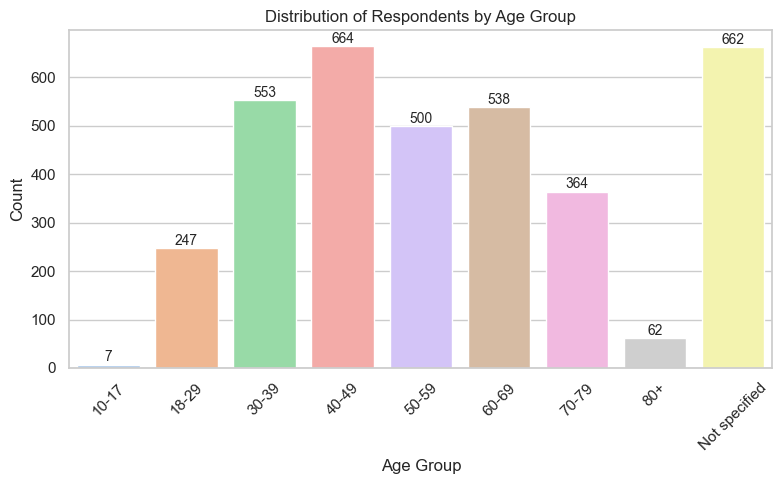

In [136]:
# Distribution of Age
AGE_ORDER = ['10-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+', 'Not specified']

# Keep only values that actually appear in the data (avoids KeyError if a range is absent)
age_order_present = [a for a in AGE_ORDER if a in df['Age group'].values]

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Age group', order=age_order_present, palette='pastel', ax=ax)
ax.set_title('Distribution of Respondents by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height() + 0.5,
            str(int(p.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#### Invalidity

In [137]:
df['Invalidity_clean'].value_counts()

Invalidity_clean
No group                               3050
Person with disability                  501
No group - significant difficulties      41
Disability due to war                     5
Name: count, dtype: int64

C:\Users\cdegr\AppData\Local\Temp\ipykernel_572\511123885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Invalidity_clean', palette='pastel',


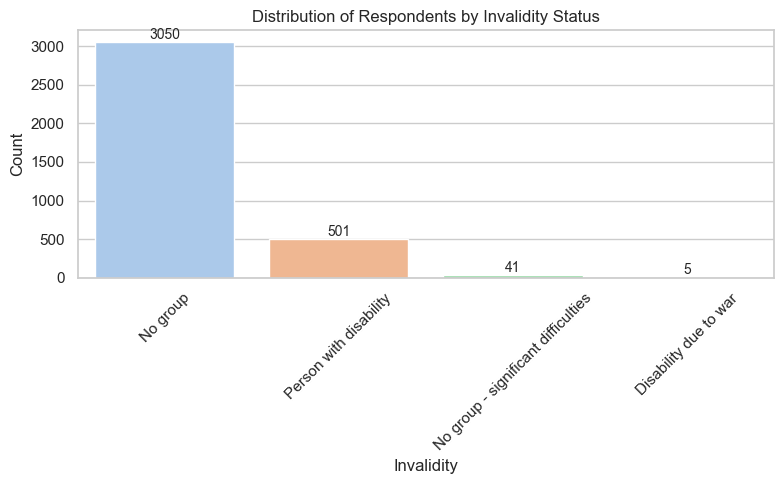

In [138]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Invalidity_clean', palette='pastel',
              order=df['Invalidity_clean'].value_counts().index, ax=ax)
ax.set_title('Distribution of Respondents by Invalidity Status')
ax.set_xlabel('Invalidity')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height() + 0.5,
            str(int(p.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Region

In [139]:
print(df['Region'].value_counts().sort_index())

Region
Autonomous Republic of Crimea      1
Cherkasy                         121
Chernihiv                        143
Chernivtsi                        77
Dnipropetrovsk                   349
Donetsk                           80
Ivano-Frankivsk                   92
Kharkiv                          375
Kherson                           65
Khmelnytskyi                     123
Kirovohradska                    100
Kyiv city                        351
Kyivska                          217
Luhansk                            1
Lvivska                          168
Mykolaivska                      136
Not specified                    102
Odesa                            154
Poltava                          136
Rivne                             70
Sumy                             150
Ternopil                          60
Transcarpathian                   52
Vinnytsia                        157
Volynska                          74
Zaporizhzhia                     160
Zhytomyrska                    

C:\Users\cdegr\AppData\Local\Temp\ipykernel_572\960570412.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Region', order=region_order, palette='muted', ax=ax)


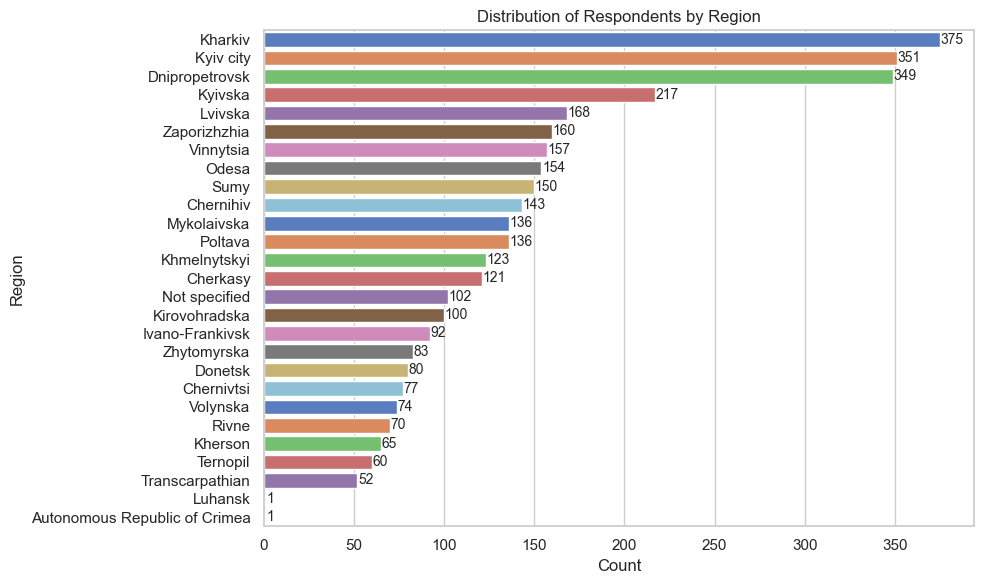

In [140]:
fig, ax = plt.subplots(figsize=(10, 6))
region_order = df['Region'].value_counts().index
sns.countplot(data=df, y='Region', order=region_order, palette='muted', ax=ax)
ax.set_title('Distribution of Respondents by Region')
ax.set_xlabel('Count')
ax.set_ylabel('Region')

for p in ax.patches:
    ax.text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2.,
            str(int(p.get_width())), ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [141]:
print("Unique regions:", df['Region'].nunique())

Unique regions: 27


In [142]:
print("Unique regions:", df['Region'].unique())

Unique regions: <StringArray>
[               'Dnipropetrovsk',                       'Kharkiv',
                     'Vinnytsia',                         'Odesa',
                       'Lvivska',                       'Kherson',
                   'Mykolaivska',                       'Donetsk',
                       'Poltava',                     'Kyiv city',
                      'Volynska',                 'Not specified',
               'Ivano-Frankivsk',                          'Sumy',
                      'Ternopil',                      'Cherkasy',
                       'Kyivska',                    'Chernivtsi',
                  'Zaporizhzhia',                  'Khmelnytskyi',
                     'Chernihiv',                         'Rivne',
                   'Zhytomyrska',                 'Kirovohradska',
               'Transcarpathian',                       'Luhansk',
 'Autonomous Republic of Crimea']
Length: 27, dtype: str


#### Source of income

C:\Users\cdegr\AppData\Local\Temp\ipykernel_572\815085524.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Source of income', palette='pastel',


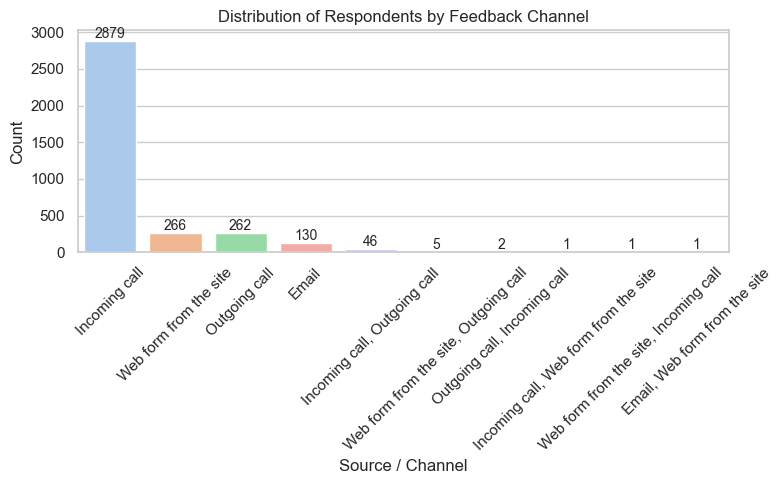

In [143]:
# Source of income	
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Source of income', palette='pastel',
              order=df['Source of income'].value_counts().index, ax=ax)
ax.set_title('Distribution of Respondents by Feedback Channel')
ax.set_xlabel('Source / Channel')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height() + 0.5,
            str(int(p.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


#### Other vulnerabilities (top N)

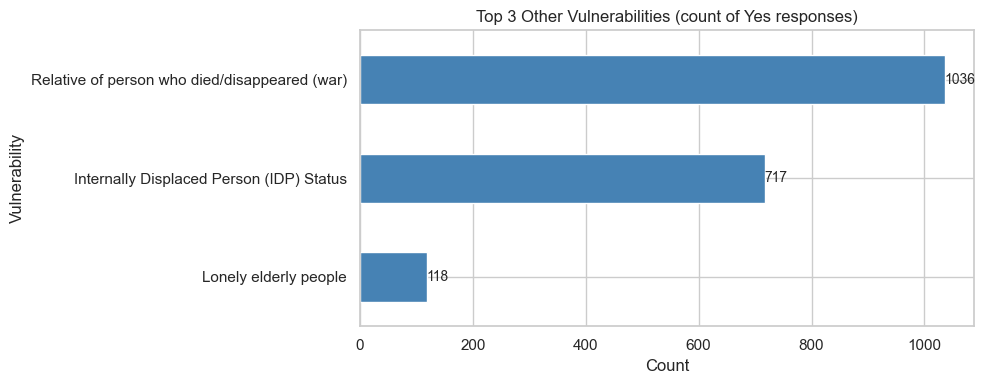

In [144]:
# Distribution of top 3 Other vulnerability dummy columns
vuln_dummy_cols = ['IDP_Status', 'Relative_Deceased_Disappeared_War', 'Lonely_Elderly']
vuln_labels = {
    'IDP_Status':        'Internally Displaced Person (IDP) Status',
    'Relative_Deceased_Disappeared_War': 'Relative of person who died/disappeared (war)',
    'Lonely_Elderly':    'Lonely elderly people',
}

# Count 'Yes' responses per dummy column
yes_counts = {vuln_labels[col]: (df[col] == 'Yes').sum() for col in vuln_dummy_cols}
yes_series = pd.Series(yes_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
yes_series.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 3 Other Vulnerabilities (count of Yes responses)')
ax.set_xlabel('Count')
ax.set_ylabel('Vulnerability')
ax.invert_yaxis()

for i, v in enumerate(yes_series):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Interactions

#### Sector x Sex heatmap

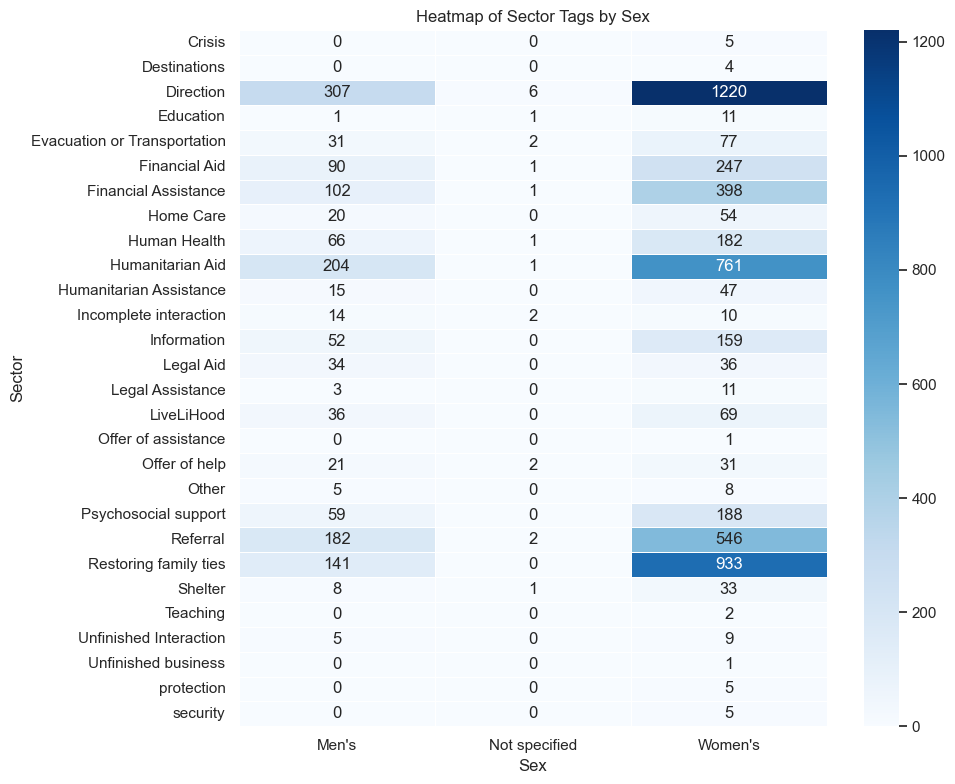

In [145]:
# Heatmap: Sector tag by Sex
sector_sex_matrix = pd.crosstab(
    df_sector_exploded.reset_index(drop=True)['Sector_list'],
    df_sector_exploded.reset_index(drop=True)['Sex']
)
plt.figure(figsize=(10, 8))
sns.heatmap(sector_sex_matrix, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Heatmap of Sector Tags by Sex')
plt.xlabel('Sex')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

#### Age x Sex

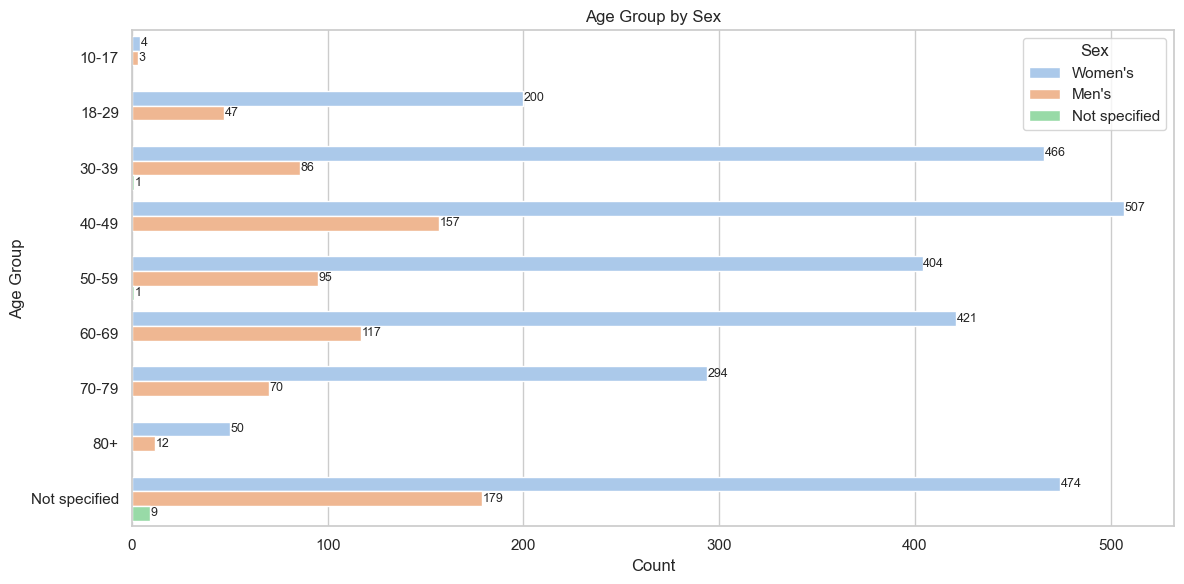

In [146]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, y='Age group', hue='Sex', order=age_order_present, palette='pastel', ax=ax)
ax.set_title('Age Group by Sex')
ax.set_xlabel('Count')
ax.set_ylabel('Age Group')
ax.legend(title='Sex')
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 0.3, p.get_y() + p.get_height() / 2.,
                str(int(width)), ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### Invalidity x Sex

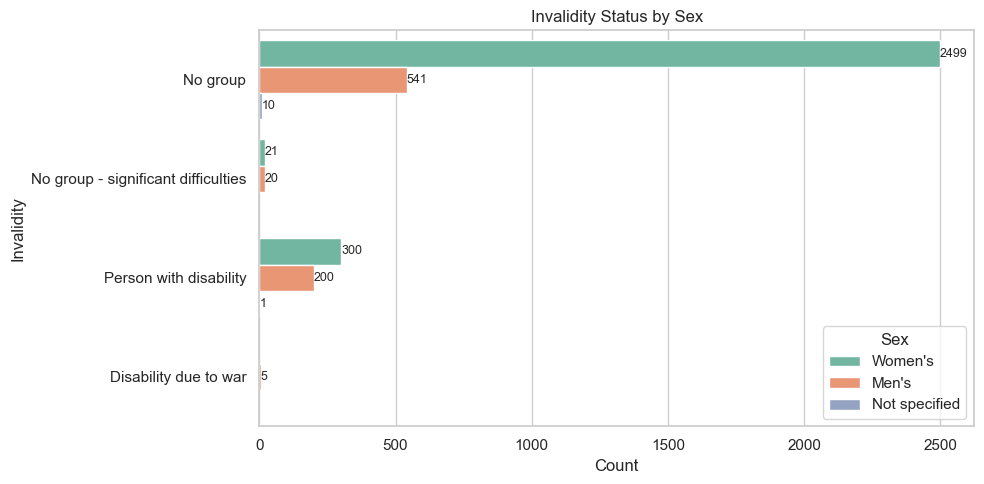

In [147]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, y='Invalidity_clean', hue='Sex', palette='Set2', ax=ax)
ax.set_title('Invalidity Status by Sex')
ax.set_xlabel('Count')
ax.set_ylabel('Invalidity')
ax.legend(title='Sex')
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 0.3, p.get_y() + p.get_height() / 2.,
                str(int(width)), ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### Sector x Age
Do certain age group dominate certain topic areas? (representation bias)

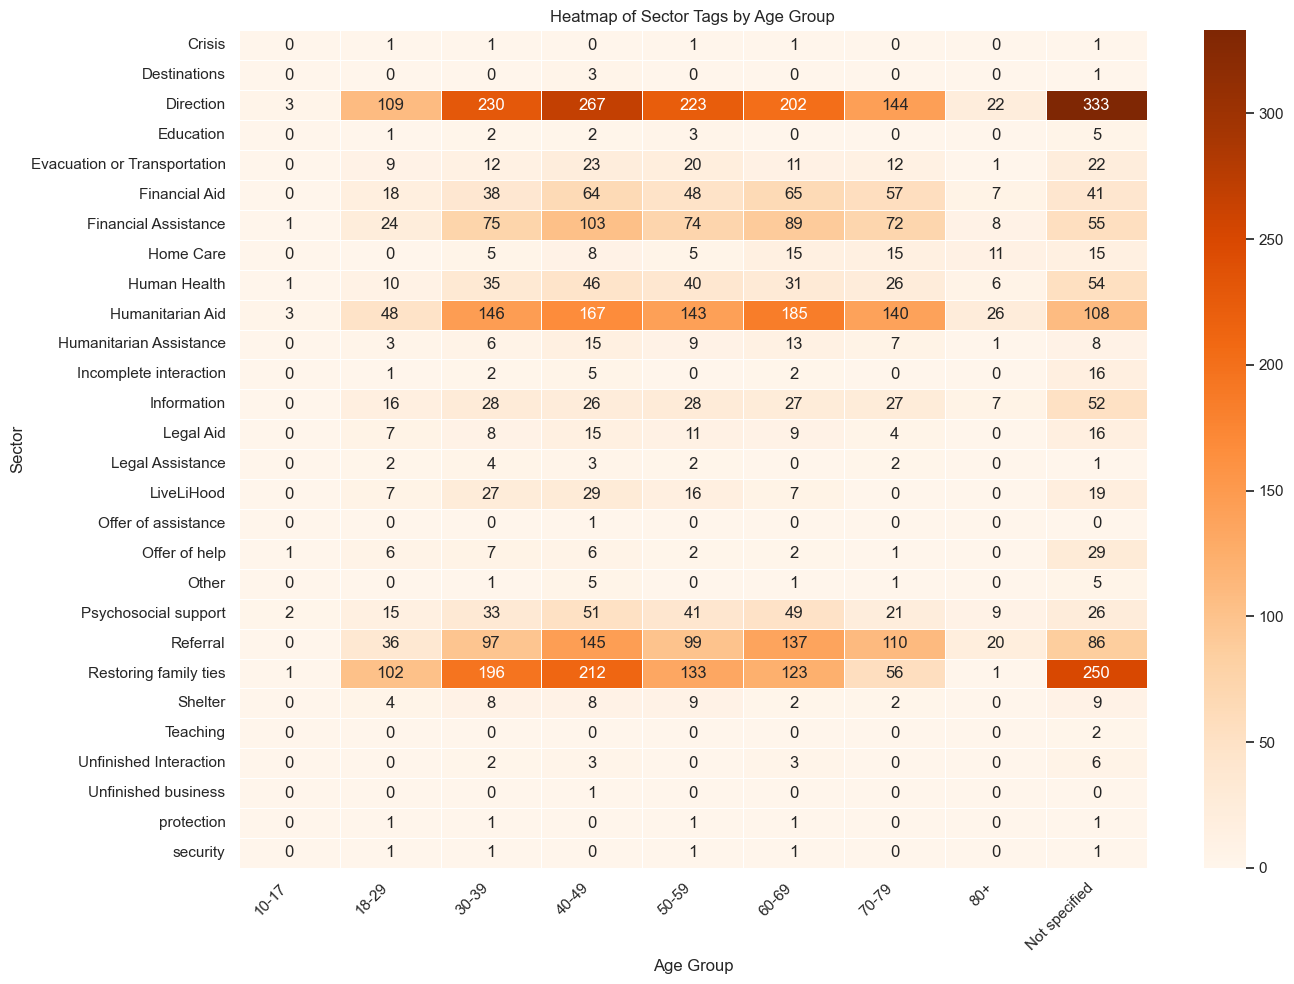

In [148]:
sector_age_matrix = pd.crosstab(
    df_sector_exploded.reset_index(drop=True)['Sector_list'],
    df_sector_exploded.reset_index(drop=True)['Age group']
)# Reorder age columns
age_cols_present = [a for a in AGE_ORDER if a in sector_age_matrix.columns]
sector_age_matrix = sector_age_matrix[age_cols_present]

plt.figure(figsize=(14, 10))
sns.heatmap(sector_age_matrix, annot=True, fmt='d', cmap='Oranges', linewidths=0.5)
plt.title('Heatmap of Sector Tags by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Sector')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Region x Sex
Geographic + demographic intersection

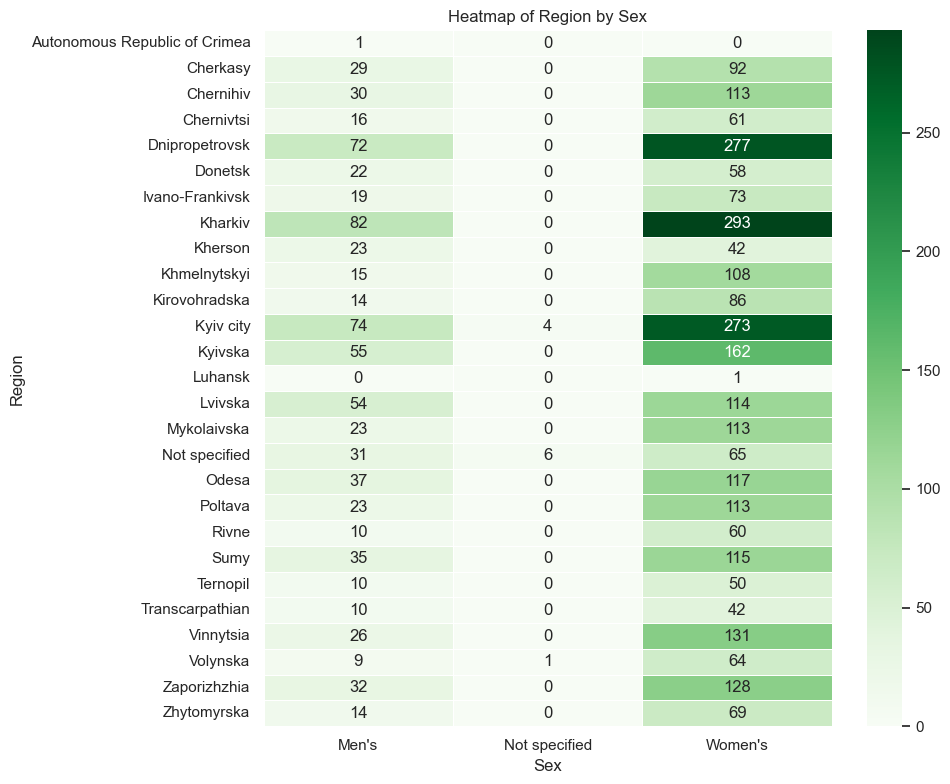

In [149]:
region_sex_matrix = pd.crosstab(df['Region'], df['Sex'])

plt.figure(figsize=(10, 8))
sns.heatmap(region_sex_matrix, annot=True, fmt='d', cmap='Greens', linewidths=0.5)
plt.title('Heatmap of Region by Sex')
plt.xlabel('Sex')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

#### Vulnerability x Sex

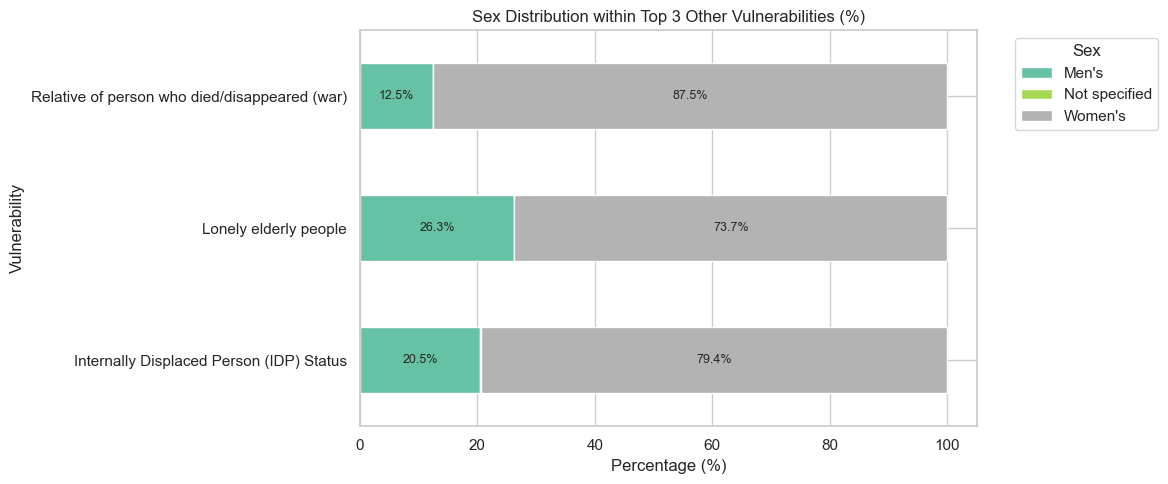

In [150]:
# Sex distribution within top 3 Other Vulnerability categories
vuln_dummy_cols = ['IDP_Status', 'Relative_Deceased_Disappeared_War', 'Lonely_Elderly']
vuln_labels = {
    'IDP_Status':        'Internally Displaced Person (IDP) Status',
    'Relative_Deceased_Disappeared_War': 'Relative of person who died/disappeared (war)',
    'Lonely_Elderly':    'Lonely elderly people',
}

# For each dummy column, compute percentage breakdown by Sex among 'Yes' rows
rows = []
for col in vuln_dummy_cols:
    sub = df[df[col] == 'Yes']
    sex_pct = sub['Sex'].value_counts(normalize=True) * 100
    for sex_val, pct in sex_pct.items():
        rows.append({'Vulnerability': vuln_labels[col], 'Sex': sex_val, 'Percentage': pct})

vuln_sex_df = pd.DataFrame(rows)
vuln_sex_pivot = vuln_sex_df.pivot(index='Vulnerability', columns='Sex', values='Percentage').fillna(0)

ax = vuln_sex_pivot.plot(kind='barh', stacked=True, figsize=(12, 5), colormap='Set2')

for col in vuln_sex_pivot.columns:
    cumulative = vuln_sex_pivot[vuln_sex_pivot.columns[:list(vuln_sex_pivot.columns).index(col)]].sum(axis=1)
    for i, (val, cum) in enumerate(zip(vuln_sex_pivot[col], cumulative)):
        if val > 3:  # skip tiny segments
            ax.text(cum + val / 2, i, f'{val:.1f}%', ha='center', va='center', fontsize=9)

plt.title('Sex Distribution within Top 3 Other Vulnerabilities (%)')
plt.xlabel('Percentage (%)')
plt.ylabel('Vulnerability')
plt.legend(title='Sex', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Insights on textual column

In [151]:
text_data = df[df['Description'].notna() & (df['Description'] != 'nan')]

In [152]:
# Calculate Character Count (total letters, numbers, spaces)
text_data['Char_Count'] = text_data['Description'].apply(len)

In [153]:
# Calculate Word Count (splitting the sentence by spaces)
text_data['Word_Count'] = text_data['Description'].apply(lambda x: len(str(x).split()))

In [154]:
text_data.head()

,APPLICATION NO.:,Description,Sector,Source of income,Region,Sex,Age group,Invalidity,Sector_list,Invalidity_clean,IDP_Status,Relative_Deceased_Disappeared_War,Lonely_Elderly,Sector_combination,Char_Count,Word_Count
0,1,"A local pensioner, 68, suffered a stroke and r...","Humanitarian aid, Directions",Incoming call,Dnipropetrovsk,Women's,60-69,No group,"[Humanitarian Aid, Direction]",No group,No,No,No,"Direction, Humanitarian Aid",183,28
1,2,The woman asked about the questionnaire that s...,"Directions, LiveLiHood",Incoming call,Kharkiv,Women's,60-69,No group,"[Direction, LiveLiHood]",No group,No,No,No,"Direction, LiveLiHood",301,51
2,3,"A woman is in a difficult psychological state,...",Psychosocial support,Incoming call,Vinnytsia,Women's,40-49,No group,[Psychosocial support],No group,No,Yes,No,Psychosocial support,1099,190
3,4,A lawyer has contacted me to help a woman (a c...,"Legal aid, Referrals",Incoming call,Odesa,Men's,Not specified,No group,"[Legal Aid, Referral]",No group,No,No,No,"Legal Aid, Referral",162,29
4,5,The man wants to work at the TCHHU.\nexplained...,LiveLiHood,Incoming call,Lvivska,Men's,Not specified,No group,[LiveLiHood],No group,No,No,No,LiveLiHood,75,14


In [155]:
# Print the summary statistics (Mean, Min, Max, Quartiles)
print("--- Summary Statistics for Feedback Length ---")
# .describe() automatically calculates count, mean, std, min, 25%, 50%, 75%, max
print(text_data[['Char_Count', 'Word_Count']].describe().round(2))

--- Summary Statistics for Feedback Length ---
       Char_Count  Word_Count
count     3597.00     3597.00
mean       329.79       55.43
std        504.11       87.90
min          3.00        1.00
25%        129.00       20.00
50%        216.00       35.00
75%        364.00       60.00
max      14373.00     2354.00


In [ ]:
# See entry with the highest word count
max_index = text_data['Word_Count'].idxmax()

# Get the full row for that index
longest_entry = text_data.loc[max_index, "Description"]


In [157]:
text_data.columns

Index(['APPLICATION NO.:', 'Description', 'Sector', 'Source of income',
       'Region', 'Sex', 'Age group', 'Invalidity', 'Sector_list',
       'Invalidity_clean', 'IDP_Status', 'Relative_Deceased_Disappeared_War',
       'Lonely_Elderly', 'Sector_combination', 'Char_Count', 'Word_Count'],
      dtype='str')

C:\Users\cdegr\AppData\Local\Temp\ipykernel_572\1991289627.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=text_exploded, y='Sector_list', x='Word_Count',


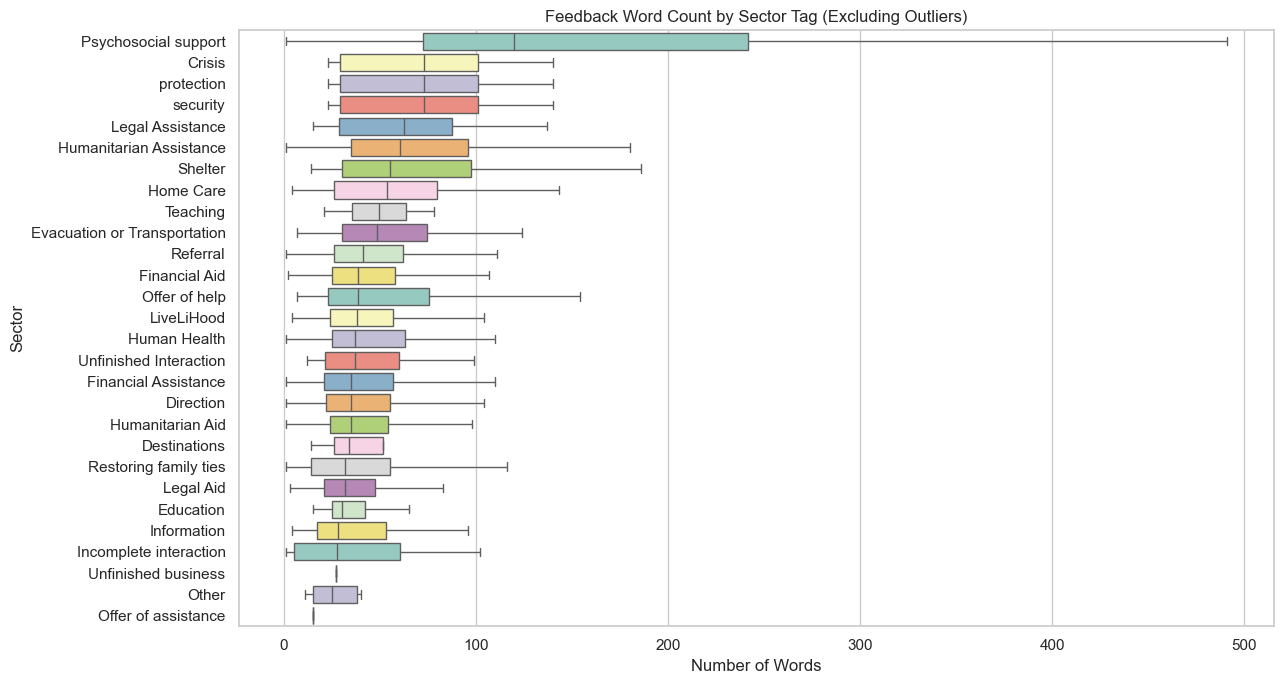

In [ ]:
# --- Visualize the Distribution of Word Counts --- #

# Word Count by Sector Tag (exploded — each entry appears once per tag it belongs to)
text_exploded = df_sector_exploded.merge(
    text_data[['APPLICATION NO.:', 'Word_Count']],
    on='APPLICATION NO.:',
    how='inner'
)

plt.figure(figsize=(13, 7))
sector_order = text_exploded.groupby('Sector_list')['Word_Count'].median().sort_values(ascending=False).index
sns.boxplot(data=text_exploded, y='Sector_list', x='Word_Count',
            order=sector_order, palette='Set3', showfliers=False)
plt.title('Feedback Word Count by Sector Tag (Excluding Outliers)')
plt.xlabel('Number of Words')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

### Save final data

In [ ]:
# --- Build final cleaned dataframe --- #
# Sector_list: cleaned list of split sector tags (the canonical final version)
# Invalidity_clean: merged invalidity groups
# Other vulnerabilities: #VALUE! replaced with NaN

df_final = df[[
    'APPLICATION NO.:',
    'Description',
    'Sector_list',           # list version with cleaned/merged tags
    # 'Source of income',
    'Region',
    'Sex',
    'Age group',
    'Invalidity_clean', # result from the mapping
    'IDP_Status',
    'Relative_Deceased_Disappeared_War',
    'Lonely_Elderly',
    # `Other vulnerabilities` has been removed as we now have 3 dummy columns for the top 3 (>100)
]].rename(columns={
    'Invalidity_clean': 'Invalidity',     # use clean version as the canonical column
    'Description': 'Feedback',            # rename to match what LLM prompts expect
})

# Sector_list contains Python lists — convert to a readable string for Excel
# (Excel can't store lists; store as semicolon-separated so it's easy to re-parse)
df_final['Sector_list'] = df_final['Sector_list'].apply(
    lambda tags: '; '.join(tags) if isinstance(tags, list) else tags
)

# Save
df_final.to_excel('Thesis_data_final.xlsx', index=False)
print(f"Saved {len(df_final)} rows to Thesis_data_final.xlsx")
print(f"Columns: {list(df_final.columns)}")

Saved 3597 rows to Thesis_data_final.xlsx
Columns: ['APPLICATION NO.:', 'Feedback', 'Sector_list', 'Region', 'Sex', 'Age group', 'Invalidity', 'IDP_Status', 'Relative_Deceased_Disappeared_War', 'Lonely_Elderly']


Test with reading back in and looking at top:

In [160]:
df_final_test = pd.read_excel('Thesis_data_final.xlsx')

In [161]:
len(df_final_test)

3597

In [162]:
df_final_test.head()

,APPLICATION NO.:,Feedback,Sector_list,Region,Sex,Age group,Invalidity,IDP_Status,Relative_Deceased_Disappeared_War,Lonely_Elderly
0,1,"A local pensioner, 68, suffered a stroke and r...",Humanitarian Aid; Direction,Dnipropetrovsk,Women's,60-69,No group,No,No,No
1,2,The woman asked about the questionnaire that s...,Direction; LiveLiHood,Kharkiv,Women's,60-69,No group,No,No,No
2,3,"A woman is in a difficult psychological state,...",Psychosocial support,Vinnytsia,Women's,40-49,No group,No,Yes,No
3,4,A lawyer has contacted me to help a woman (a c...,Legal Aid; Referral,Odesa,Men's,Not specified,No group,No,No,No
4,5,The man wants to work at the TCHHU.\nexplained...,LiveLiHood,Lvivska,Men's,Not specified,No group,No,No,No
